<a href="https://colab.research.google.com/github/jeedderh01/knowledge-check-module1/blob/main/Class_Exercise1pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resesrvior Temperature
calaulating the reservior temperature using geothermal gradient

In [1]:
def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """Calculate reservoir temperature using geothermal gradient.

    Parameters:
        depth_m: Well depth in metres
        surface_temp: Seabed surface temperature in Celsius (default 4.0)
        gradient: Geothermal gradient in deg C per km (default 30.0)
    Returns:
        Estimated temperature at depth in Celsius
    """
    if depth_m < 0:
        raise ValueError(f"Depth cannot be negative: {depth_m}")
    return surface_temp + (gradient * depth_m / 1000)

# Usan well depths
for depth in [500, 1000, 1500, 2000, 2500]:
    temp = reservoir_temperature(depth)
    print(f" Depth: {depth}m -> Temperature: {temp:.1f} deg C")

 Depth: 500m -> Temperature: 19.0 deg C
 Depth: 1000m -> Temperature: 34.0 deg C
 Depth: 1500m -> Temperature: 49.0 deg C
 Depth: 2000m -> Temperature: 64.0 deg C
 Depth: 2500m -> Temperature: 79.0 deg C


# Uploading file and Temperature calculator  
This is used to calculate the well depth temperature of a reservior using the geothermal gradient and the surface temperature.

In [16]:
def calculate_temperature(depth):
    """Calculate temperature from well depth."""
    surface_temperature = 25
    geothermal_gradient = 0.03  # °C per metre

    return surface_temperature + (depth * geothermal_gradient)
import pandas as pd

# Read the CSV file
df = pd.read_csv("/content/sample_data/well_depths.csv")

# Calculate temperature for every well
df["temperature"] = df["depth_m"].apply(calculate_temperature)

# Display the results
print(df)

# Save the results to a new CSV file
df.to_csv("well_depths_with_temperature.csv", index=False)

     well_id  depth_m  temperature
0   WELL_001  1354.89      65.6467
1   WELL_002  3054.61     116.6383
2   WELL_003  2409.38      97.2814
3   WELL_004  2016.04      85.4812
4   WELL_005   710.25      46.3075
5   WELL_006   710.18      46.3054
6   WELL_007   421.35      37.6405
7   WELL_008  2805.22     109.1566
8   WELL_009  2023.29      85.6987
9   WELL_010  2338.81      95.1643
10  WELL_011   310.72      34.3216
11  WELL_012  3111.23     118.3369
12  WELL_013  2705.71     106.1713
13  WELL_014   876.40      51.2920
14  WELL_015   786.38      48.5914
15  WELL_016   791.04      48.7312
16  WELL_017  1147.51      59.4253
17  WELL_018  1798.03      78.9409
18  WELL_019  1524.24      70.7272
19  WELL_020  1109.13      58.2739
20  WELL_021  2054.97      86.6491
21  WELL_022   661.51      44.8453
22  WELL_023  1111.83      58.3549
23  WELL_024  1330.77      64.9231
24  WELL_025  1595.41      72.8623
25  WELL_026  2566.27     101.9881
26  WELL_027   839.04      50.1712
27  WELL_028  1766.9

#Temperature vs. Depth Scatter Plot

The following Python code creates a scatter plot of temperature against well depth and adds a linear trendline.:

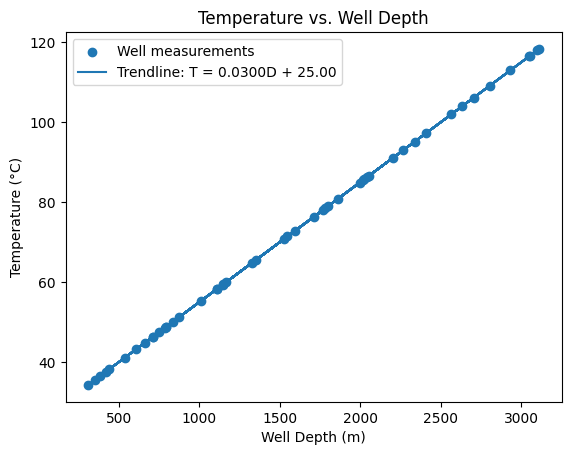

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = pd.read_csv("well_depths_with_temperature.csv")

# Get depth and temperature data
depth = df["depth_m"]
temperature = df["temperature"]

# Calculate linear trendline
slope, intercept = np.polyfit(depth, temperature, 1)

# Calculate trendline values
trendline = slope * depth + intercept

# Create scatter plot
plt.scatter(depth, temperature, label="Well measurements")

# Add linear trendline
plt.plot(
    depth,
    trendline,
    label=f"Trendline: T = {slope:.4f}D + {intercept:.2f}"
)

# Add labels and title
plt.xlabel("Well Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs. Well Depth")

# Add legend
plt.legend()

# Display the plot
plt.show()

# Temperature calculator with error handling
checking for:
* Negative depth → raise a ValueError
* Non-numeric depth → raise a TypeError
* Valid depth → calculate the temperature normally

In [18]:
def calculate_temperature(depth):
    """Calculate temperature from well depth of the reservoir."""

    # Check if depth is a number
    if not isinstance(depth, (int, float)):
        raise TypeError("Depth must be a number.")

    # Check if depth is negative
    if depth < 0:
        raise ValueError("Depth cannot be negative.")

    surface_temperature = 25
    geothermal_gradient = 0.03  # °C per metre

    return surface_temperature + (depth * geothermal_gradient)


# Test Case 1: Valid depth
print(calculate_temperature(1000))

# Test Case 2: Negative depth
try:
    print(calculate_temperature(-500))
except ValueError as error:
    print(error)

# Test Case 3: Non-numeric input
try:
    print(calculate_temperature("1000"))
except TypeError as error:
    print(error)

55.0
Depth cannot be negative.
Depth must be a number.
